## 5-2 频繁1项集Top结果

In [21]:
import sys
from pathlib import Path

# 目的：初始化 notebook 运行环境，确保可导入 backend 下服务模块
BACKEND_DIR = Path.cwd().resolve().parent
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

In [22]:
import pandas as pd
from services.apriori import get_rules_summary

# 目的：一次性加载规则、频繁1项集和频繁2项集，供后续各小节复用
rules, frequent_1, frequent_2 = get_rules_summary()

In [23]:
# 目的：展示频繁1项集 Top10（按支持度降序）
f1 = pd.DataFrame(frequent_1).sort_values("support", ascending=False)
f1.head(10)

,item,count,support
0,奥利奥脆脆奶茶,1014,0.084038
1,芝士蛋糕,979,0.081137
2,薯条,861,0.071358
3,芒果爆柠奶茶,857,0.071026
4,炸鸡块,853,0.070695
5,鸡米花,839,0.069534
6,百香果绿茶,795,0.065888
7,焦糖布丁奶茶,789,0.065390
8,玫瑰荔枝奶茶,769,0.063733
9,多多绿茶奶茶,764,0.063318


## 5-3 频繁2项集Top结果

In [24]:
# 目的：展示频繁2项集 Top10（按支持度降序）
f2 = pd.DataFrame(frequent_2).sort_values("support", ascending=False)
f2.head(10)

,pair,count,support
0,"(奥利奥脆脆奶茶, 芝士蛋糕)",586,0.048566
1,"(多多绿茶奶茶, 薯条)",405,0.033565
2,"(焦糖布丁奶茶, 鸡米花)",397,0.032902
3,"(炸鸡块, 芝士奶盖抹茶)",375,0.031079
4,"(百香果绿茶, 芒果爆柠奶茶)",373,0.030913
5,"(玫瑰荔枝奶茶, 甜甜圈（草莓巧克力）)",356,0.029504
6,"(鸡米花, 黑糖珍珠奶茶)",54,0.004475
7,"(火龙果椰香奶茶, 草莓芝士奶盖)",52,0.004310
8,"(杨枝甘露奶茶, 柚子蜂蜜奶茶)",50,0.004144
9,"(橙香茉莉奶茶, 芒果爆柠奶茶)",50,0.004144


## 5-4 强关联规则结果示例

In [25]:
# 目的：展示强关联规则示例（按置信度和提升度降序）
r = pd.DataFrame(rules).sort_values(["confidence", "lift"], ascending=False)
r.head(15)[["lhs", "rhs", "support", "confidence", "lift", "level"]]

,lhs,rhs,support,confidence,lift,level
0,芝士蛋糕,奥利奥脆脆奶茶,0.048566,0.598570,7.122628,L1
1,奥利奥脆脆奶茶,芝士蛋糕,0.048566,0.577909,7.122628,L1
2,多多绿茶奶茶,薯条,0.033565,0.530105,7.428854,L1
3,芝士奶盖抹茶,炸鸡块,0.031079,0.523743,7.408538,L1
4,焦糖布丁奶茶,鸡米花,0.032902,0.503169,7.236272,L1
5,鸡米花,焦糖布丁奶茶,0.032902,0.473182,7.236272,L1
6,薯条,多多绿茶奶茶,0.033565,0.470383,7.428854,L1
7,百香果绿茶,芒果爆柠奶茶,0.030913,0.469182,6.605781,L1
8,炸鸡块,芝士奶盖抹茶,0.031079,0.439625,7.408538,L1
9,芒果爆柠奶茶,百香果绿茶,0.030913,0.435239,6.605781,L1


## 5-5 规则分级统计结果（L1-L4）

In [26]:
# 目的：统计各等级规则数量（L1~L4）
r["level"].value_counts()

level
L1    10
Name: count, dtype: int64

In [27]:
# 目的：查看各等级规则的平均支持度、置信度和提升度
r.groupby("level")[["support", "confidence", "lift"]].mean()

,support,confidence,lift
level,,,
L1,0.035405,0.502111,7.160415


In [28]:
# 目的：按固定顺序输出 L1~L4 规则分级统计结果
level_counts = r["level"].value_counts().reindex(["L1", "L2", "L3", "L4"], fill_value=0)
level_counts

level
L1    10
L2     0
L3     0
L4     0
Name: count, dtype: int64

## 5-1 Apriori参数配置与事务输入规模

TX_WINDOW_DAYS = 180
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.1
MIN_SUPPORT_ITEMSET = 0.003


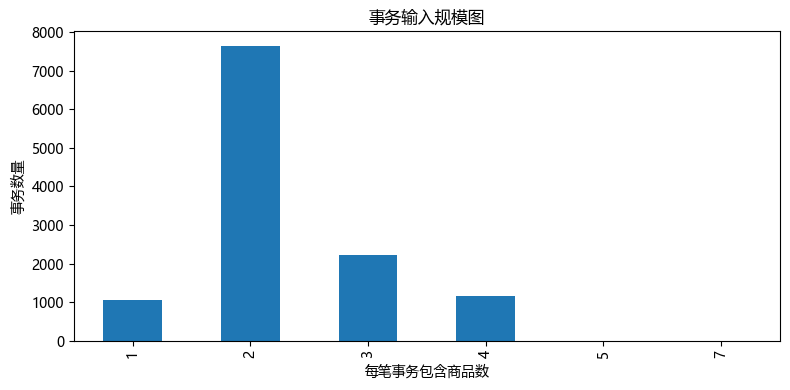

In [29]:
from services.apriori import (
    MIN_CONFIDENCE,
    MIN_SUPPORT,
    MIN_SUPPORT_ITEMSET,
    TX_WINDOW_DAYS,
    load_transactions,
)
import matplotlib.pyplot as plt

# 目的：展示 Apriori 参数配置，并可视化事务输入规模分布
print(f"TX_WINDOW_DAYS = {TX_WINDOW_DAYS}")
print(f"MIN_SUPPORT = {MIN_SUPPORT}")
print(f"MIN_CONFIDENCE = {MIN_CONFIDENCE}")
print(f"MIN_SUPPORT_ITEMSET = {MIN_SUPPORT_ITEMSET}")

# 兼容中文标题显示（Windows 常见字体）
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

transactions = load_transactions()
transaction_sizes = [len(t) for t in transactions]
size_dist = pd.Series(transaction_sizes, name="items_per_tx").value_counts().sort_index()

ax = size_dist.plot(kind="bar", figsize=(8, 4))
ax.set_xlabel("每笔事务包含商品数")
ax.set_ylabel("事务数量")
ax.set_title("事务输入规模图")

plt.tight_layout()
plt.show()

## 5-6 模型接口结果复现（替代网页控制台）

本小节用 Notebook 直接复现 `/gold/recommend` 的返回结果，只展示输入与输出结果，不使用浏览器控制台代码。

In [30]:
from services.apriori import get_custom_recommend

# 等价于请求体：{"items": ["芝士蛋糕"]}
test_items = ["芝士蛋糕"]
recommend_result = get_custom_recommend(test_items, top_n=5)

print("接口输入 items:", test_items)
print("接口返回 recommend:")
pd.DataFrame(recommend_result)

接口输入 items: ['芝士蛋糕']
接口返回 recommend:


,item,score
0,奥利奥脆脆奶茶,4.263391


In [31]:
# 边界场景：空输入（等价于 {"items": []}）
empty_items = []
empty_result = get_custom_recommend(empty_items, top_n=5)

print("空输入 items:", empty_items)
print("空输入返回 recommend:")
pd.DataFrame(empty_result)

空输入 items: []
空输入返回 recommend:


""


## 5-7 模型性能评估图表（可用于论文5.6）

本小节从规则质量、响应时效、规则覆盖率三个维度给出图表化结果，便于直接截图放入论文“5.6 模型性能评估”。

,维度,指标
0,规则质量,"置信度均值=0.5021, 提升度均值=7.1604"
1,响应时效,"平均=259.81ms, P90=269.56ms"
2,覆盖率,覆盖率=17.54% (10/57)


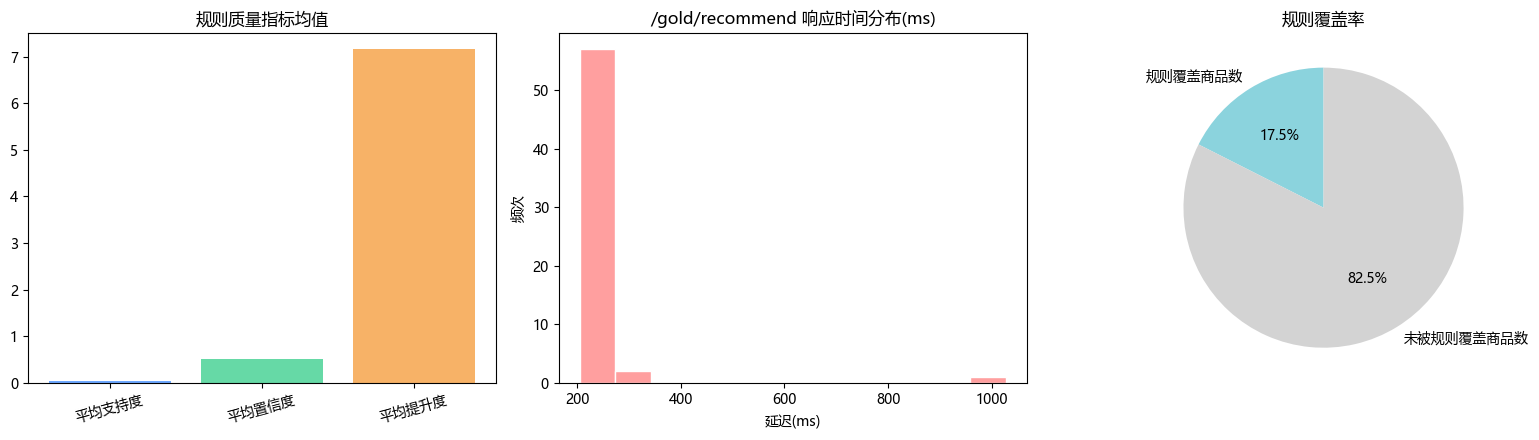

响应时效统计:
 {'平均响应(ms)': 259.815, 'P50(ms)': 243.344, 'P90(ms)': 269.56, '最大响应(ms)': 1026.333}
规则覆盖率: 17.54% (10/57)


In [34]:
import time
import numpy as np
import matplotlib.pyplot as plt
from services.apriori import get_custom_recommend

# 1) 规则质量指标（均值）
rule_quality = pd.DataFrame({
    "指标": ["平均支持度", "平均置信度", "平均提升度"],
    "数值": [
        float(r["support"].mean()) if len(r) else 0,
        float(r["confidence"].mean()) if len(r) else 0,
        float(r["lift"].mean()) if len(r) else 0,
    ],
})

# 2) 接口响应时间（本地函数调用模拟，单位 ms）
sample_items = [["芝士蛋糕"], ["奥利奥脆脆奶茶"], ["多多绿茶奶茶"], ["炸鸡块"], ["百香果绿茶"]]
latency_ms = []
for i in range(60):
    items = sample_items[i % len(sample_items)]
    t0 = time.perf_counter()
    _ = get_custom_recommend(items, top_n=5)
    t1 = time.perf_counter()
    latency_ms.append((t1 - t0) * 1000)

latency_arr = np.array(latency_ms)
latency_summary = {
    "平均响应(ms)": float(latency_arr.mean()),
    "P50(ms)": float(np.percentile(latency_arr, 50)),
    "P90(ms)": float(np.percentile(latency_arr, 90)),
    "最大响应(ms)": float(latency_arr.max()),
}

# 3) 规则覆盖率（规则涉及商品 / 可挖掘商品）
items_in_rules = set(r["lhs"]).union(set(r["rhs"])) if len(r) else set()
items_in_frequent = set(f1["item"]) if len(f1) else set()
coverage_ratio = (len(items_in_rules) / len(items_in_frequent)) if len(items_in_frequent) else 0

coverage_df = pd.DataFrame({
    "类别": ["规则覆盖商品数", "未被规则覆盖商品数"],
    "数量": [len(items_in_rules), max(len(items_in_frequent) - len(items_in_rules), 0)],
})

# 汇总表（可直接放论文）
perf_table = pd.DataFrame({
    "维度": ["规则质量", "响应时效", "覆盖率"],
    "指标": [
        f"置信度均值={rule_quality.loc[1, '数值']:.4f}, 提升度均值={rule_quality.loc[2, '数值']:.4f}",
        f"平均={latency_summary['平均响应(ms)']:.2f}ms, P90={latency_summary['P90(ms)']:.2f}ms",
        f"覆盖率={coverage_ratio:.2%} ({len(items_in_rules)}/{len(items_in_frequent)})",
    ]
})

display(perf_table)

# 图表输出
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 图1：规则质量
axes[0].bar(rule_quality["指标"], rule_quality["数值"], color=["#6ea8fe", "#66d9a6", "#f7b267"])
axes[0].set_title("规则质量指标均值")
axes[0].tick_params(axis="x", rotation=15)

# 图2：接口响应时间分布
axes[1].hist(latency_arr, bins=12, color="#ff9f9f", edgecolor="white")
axes[1].set_title("/gold/recommend 响应时间分布(ms)")
axes[1].set_xlabel("延迟(ms)")
axes[1].set_ylabel("频次")

# 图3：规则覆盖率
axes[2].pie(
    coverage_df["数量"],
    labels=coverage_df["类别"],
    autopct="%.1f%%",
    startangle=90,
    colors=["#8bd3dd", "#d3d3d3"],
)
axes[2].set_title("规则覆盖率")

plt.tight_layout()
plt.show()

print("响应时效统计:\n", {k: round(v, 3) for k, v in latency_summary.items()})
print(f"规则覆盖率: {coverage_ratio:.2%} ({len(items_in_rules)}/{len(items_in_frequent)})")